# Zenith Real Estate Price Predictor

## Overview

This project develops a machine learning model capable of predicting residential property prices using the Ames Housing Dataset.

The objective is to assist buyers, sellers, investors, and real estate agencies in estimating fair market values based on housing characteristics.

## Business Goal

- Improve property valuation accuracy
- Understand major price drivers
- Build an interpretable predictive model
- Deploy a practical pricing solution

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import (
    SimpleImputer
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

import joblib
from pathlib import Path

sns.set_style("whitegrid")

---
## 1. Load Dataset

In [2]:
df = pd.read_csv("../data/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


---
## 2. Initial Exploration

In [3]:
df.shape

(2930, 82)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [6]:
df.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2348,2349,527355060,60,RL,81.0,10530,Pave,NaN,Reg,Lvl,...,0,NaN,GdPrv,NaN,0,7,2006,WD,Normal,188900
2370,2371,527451450,160,RM,21.0,1680,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,89000
1674,1675,527427200,120,RH,26.0,10943,Pave,NaN,IR2,Lvl,...,0,NaN,NaN,NaN,0,10,2007,WD,Normal,177000
1620,1621,527126030,120,RL,41.0,5330,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,251000
266,267,907280040,60,RL,75.0,9375,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,240000


---
## 3. Data Quality Assessment

### Missing Values

In [7]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
).head(20)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

### Missing Value Percentage

In [8]:
missing_percentage = (
    missing / len(df)
) * 100

missing_percentage.sort_values(
    ascending=False
).head(20)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
dtype: float64

### Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(0)

---
## 4. Exploratory Data Analysis (EDA)

### Target Distribution

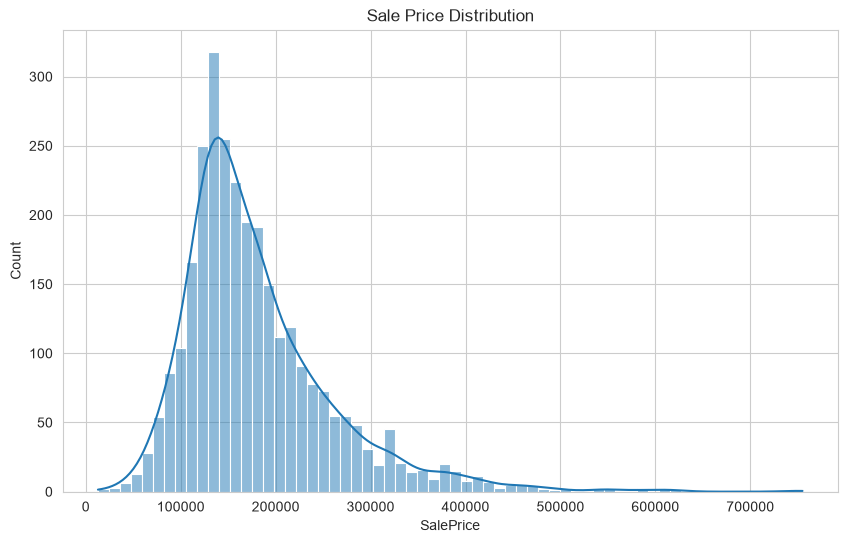

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Sale Price Distribution")

plt.show()

### Log Target Distribution

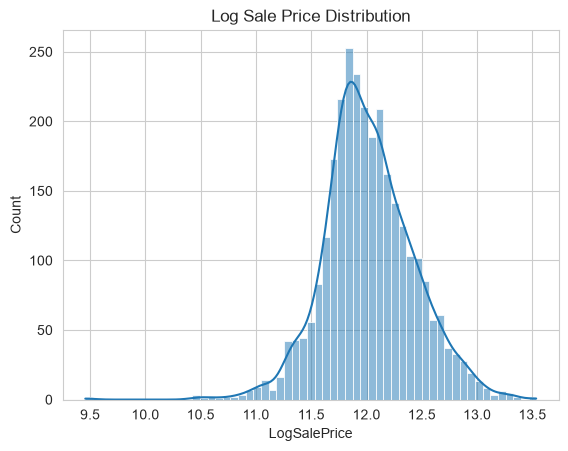

In [11]:
df["LogSalePrice"] = np.log1p(
    df["SalePrice"]
)

sns.histplot(
    df["LogSalePrice"],
    kde=True
)

plt.title(
    "Log Sale Price Distribution"
)

plt.show()

### Correlation Analysis

In [12]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_df.corr()

In [13]:
top_corr = corr_matrix[
    "SalePrice"
].sort_values(
    ascending=False
)

top_corr.head(15)

SalePrice         1.000000
LogSalePrice      0.946304
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
Name: SalePrice, dtype: float64

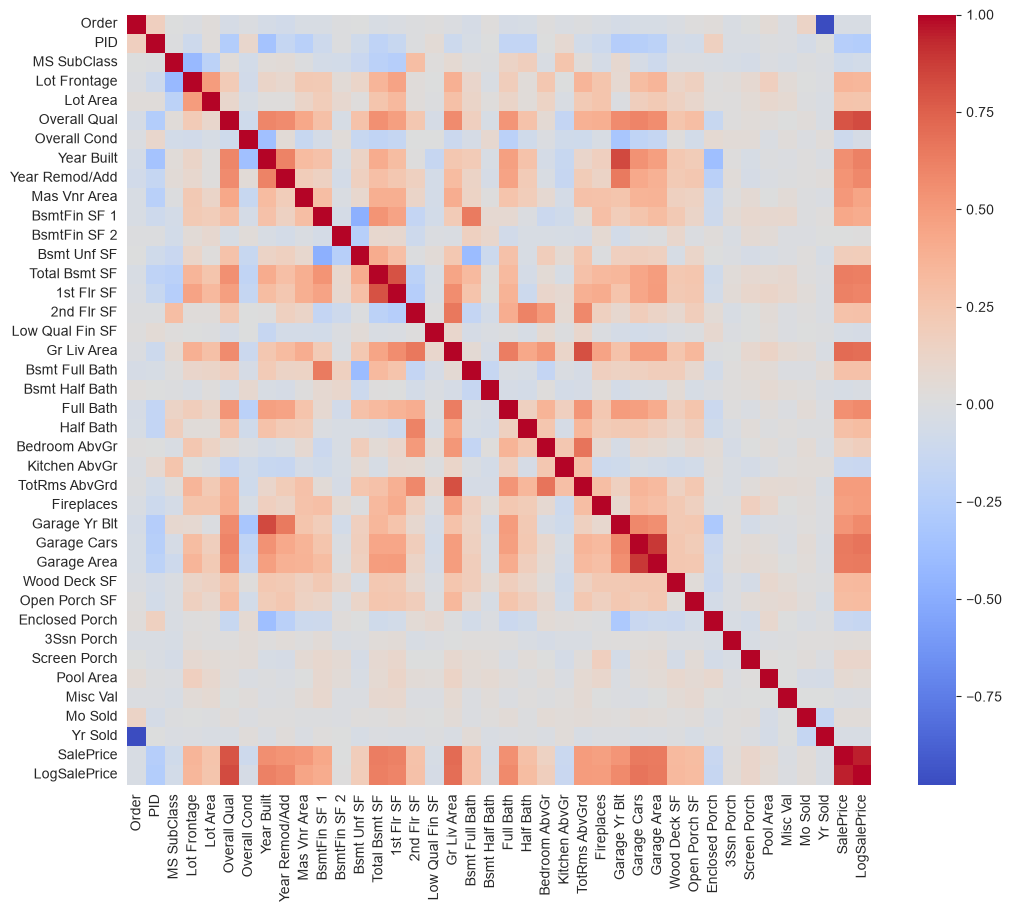

In [14]:
plt.figure(
    figsize=(12,10)
)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.show()

### Top Features vs SalePrice

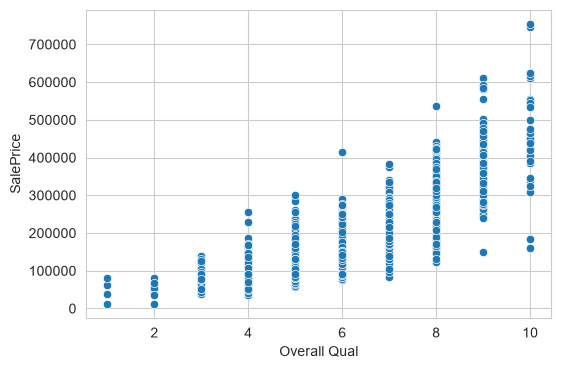

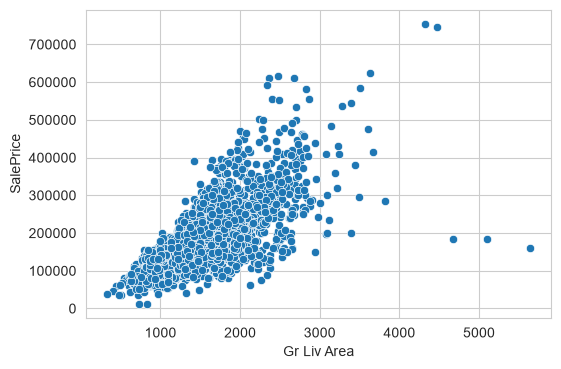

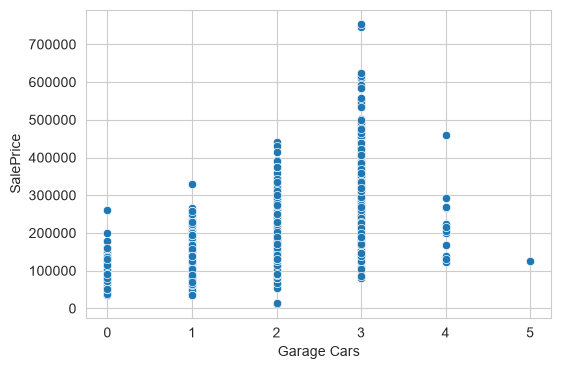

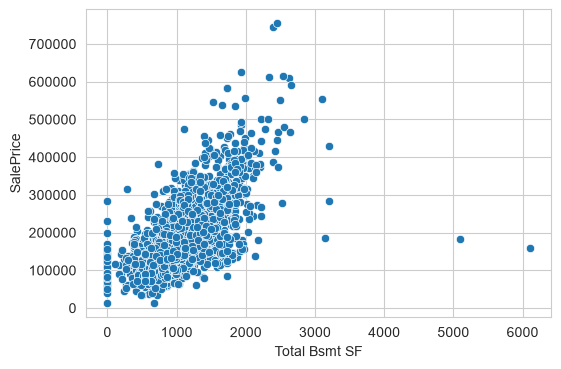

In [15]:
important_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Total Bsmt SF"
]

for col in important_features:

    plt.figure(
        figsize=(6,4)
    )

    sns.scatterplot(
        data=df,
        x=col,
        y="SalePrice"
    )

    plt.show()

---
## 5. Feature Engineering

In [16]:
# House Age
df["HouseAge"] = (
    df["Yr Sold"] -
    df["Year Built"]
)

# Remodel Age
df["RemodelAge"] = (
    df["Yr Sold"] -
    df["Year Remod/Add"]
)

# Total Bathrooms
df["TotalBathrooms"] = (
    df["Full Bath"]
    + 0.5 * df["Half Bath"]
    + df["Bsmt Full Bath"]
    + 0.5 * df["Bsmt Half Bath"]
)

# Total Area
df["TotalArea"] = (
    df["Gr Liv Area"]
    + df["Total Bsmt SF"]
)

---
## 6. Preprocessing

### Target Variable

In [17]:
y = df["SalePrice"]

X = df.drop(
    [
        "SalePrice",
        "LogSalePrice"
    ],
    axis=1
)

### Numerical Features

In [18]:
num_features = X.select_dtypes(
    include=np.number
).columns

### Categorical Features

In [19]:
cat_features = X.select_dtypes(
    exclude=np.number
).columns

### Preprocessing Pipelines

In [20]:
num_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [21]:
cat_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [22]:
preprocessor = ColumnTransformer([
    (
        "num",
        num_pipeline,
        num_features
    ),
    (
        "cat",
        cat_pipeline,
        cat_features
    )
])

---
## 7. Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

---
## 8. Model Comparison

In [24]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            random_state=42
        )
}

In [25]:
results = []

In [26]:
for name, model in models.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    preds = pipeline.predict(
        X_test
    )

    results.append([
        name,
        mean_absolute_error(
            y_test,
            preds
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                preds
            )
        ),
        r2_score(
            y_test,
            preds
        )
    ])

---
## 9. Results Table

In [27]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
3,XGBoost,14819.559570,22893.428227,0.934630
2,Gradient Boosting,14870.180768,23243.263087,0.932617
1,Random Forest,15883.580478,25828.207230,0.916795
0,Linear Regression,16121.411931,29822.510521,0.889071


---
## 10. Hyperparameter Tuning

In [28]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

In [29]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        n_estimators=200
    ))
])

In [30]:
search = RandomizedSearchCV(
    xgb_pipeline,
    param_grid,
    n_iter=3,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

---
## 11. Final Model Evaluation

In [31]:
best_model = search.best_estimator_

In [32]:
predictions = best_model.predict(
    X_test
)

In [33]:
print(
    "R2:",
    r2_score(
        y_test,
        predictions
    )
)

R2: 0.933085024356842


In [34]:
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
)

RMSE: 23162.33839662999


---
## 12. Residual Analysis

In [35]:
residuals = y_test - predictions

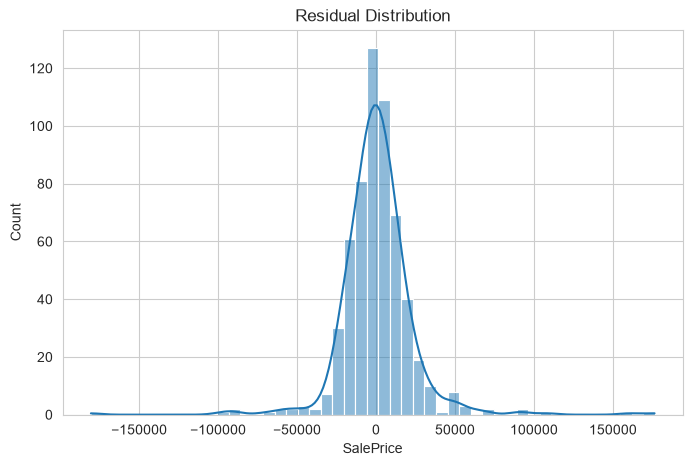

In [36]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

---
## 13. Save Model

In [37]:
MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save model
joblib.dump(
    best_model,
    MODEL_DIR / "zenith_price_predictor.pkl"
)

print("Model saved successfully!")

Model saved successfully!


---
## 14. Model Explainability with SHAP


### Prepare SHAP Explainer

We extract the fitted preprocessor and the XGBoost model from the best pipeline, transform the test set the same way the model saw it during training, and build a `TreeExplainer` (fast, exact SHAP values for tree-based models).

In [38]:
import shap
import scipy.sparse as sp

# Extract fitted preprocessor and model from the best pipeline
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_model = best_model.named_steps["model"]

# Transform the test set exactly as the model saw it
X_test_transformed = fitted_preprocessor.transform(X_test)

if sp.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

# Get readable feature names after preprocessing (numeric + one-hot encoded categorical)
feature_names = fitted_preprocessor.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Build the SHAP explainer for the tree-based XGBoost model
explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer.shap_values(X_test_transformed_df)

print("SHAP values shape:", shap_values.shape)


SHAP values shape: (586, 306)


### Global Feature Importance — Summary Plot

This shows which features matter most across all test predictions, and whether high or low values of each feature push the predicted price up or down. Each dot is one house; color = feature value (red = high, blue = low); position on the x-axis = impact on the predicted SalePrice.

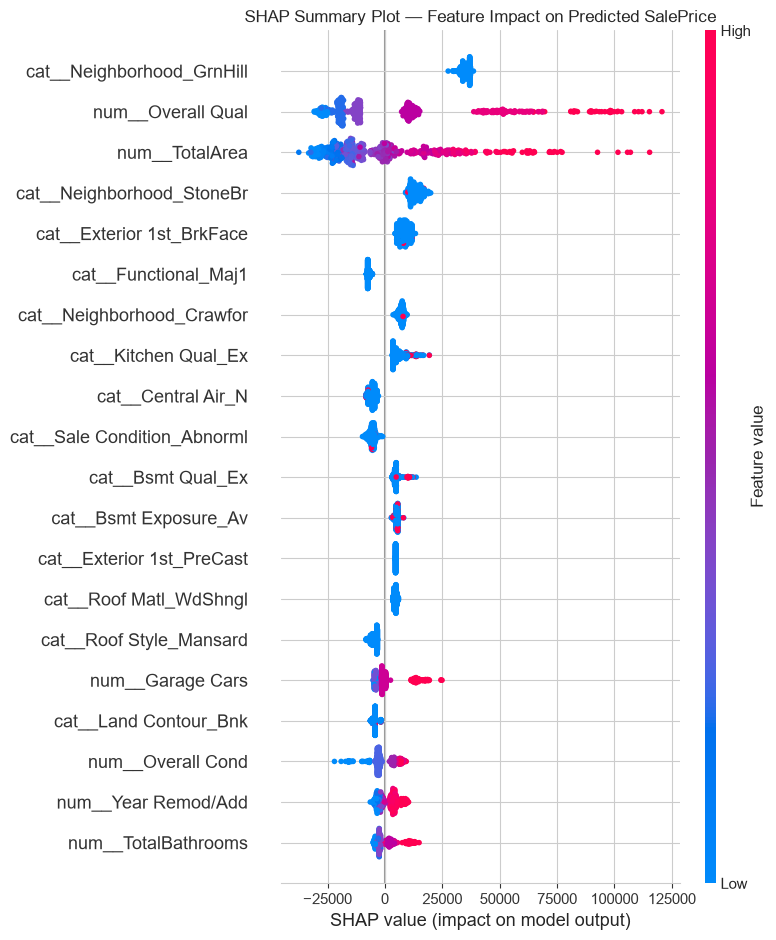

In [39]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    show=False
)
plt.title("SHAP Summary Plot — Feature Impact on Predicted SalePrice")
plt.tight_layout()
plt.show()


### (Optional) Feature Importance — Bar Plot

A simpler view: mean absolute SHAP value per feature, ranked top to bottom.

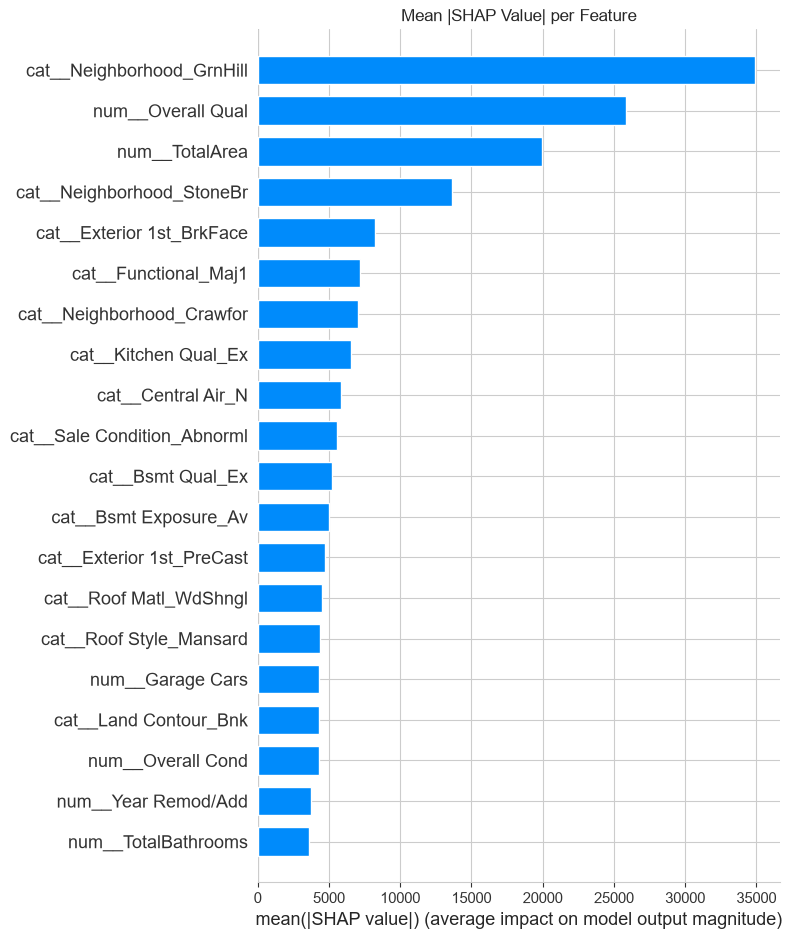

In [40]:
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    plot_type="bar",
    show=False
)
plt.title("Mean |SHAP Value| per Feature")
plt.tight_layout()
plt.show()


### Local Explanation — Waterfall Plot for a Single Prediction

This breaks down **one individual prediction** — how the model went from its baseline (average) prediction to the final predicted price for a single house, feature by feature.

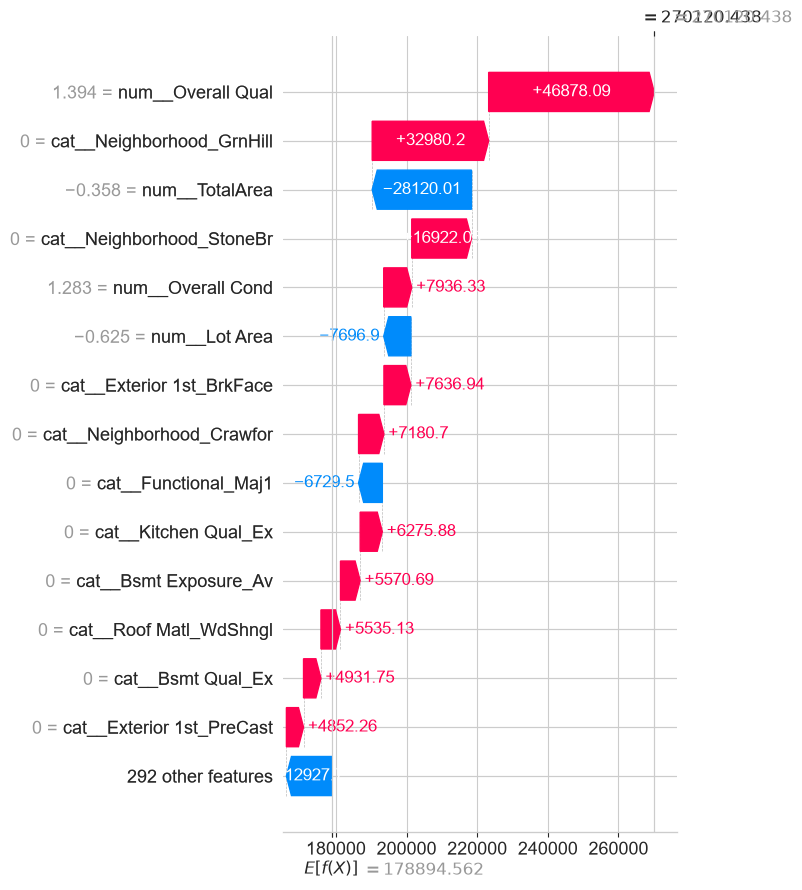

Actual SalePrice:    $161,000
Predicted SalePrice: $180,311


In [41]:
# Pick a single test-set house to explain (change the index to inspect others)
sample_idx = 0

sample_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed_df.iloc[sample_idx],
    feature_names=feature_names
)

shap.plots.waterfall(sample_explanation, max_display=15, show=False)
plt.tight_layout()
plt.show()

actual_price = y_test.iloc[sample_idx]
predicted_price = predictions[sample_idx]
print(f"Actual SalePrice:    ${actual_price:,.0f}")
print(f"Predicted SalePrice: ${predicted_price:,.0f}")


# Business Insights

1. Overall Quality is one of the strongest drivers of property prices.

2. Living Area and Basement Size have significant influence on valuation.

3. Garage capacity positively impacts property value.

4. Ensemble models outperform traditional regression models.

5. The developed model can support real estate pricing decisions and investment analysis.

# Future Work

- Integrate geospatial information
- Deploy using Streamlit
- Add explainable AI using SHAP
- Incorporate current market trends
- Build an API for real-time predictions